# Data Mining Project Template (GitHub + Colab)
## Your Name:
**Eric Bass**
## Date:
Deliverable 1: April 13th, 2026

Deliverable 2: April 20th, 2026

Deliverable 3: April 29th, 2026
## Project Title: **An Exploration of Heart Disease**
## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [33]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()

# scikit-learn tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             classification_report, cohen_kappa_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Deliverable 1: Problem Framing & Data Acquisition

## What to include in this markdown cell

**Dataset -** Heart Disease | https://archive.ics.uci.edu/dataset/45/heart+disease

**Problem Statement -** The goal is to predict the presence or absence of cardiovascular disease in a patient based on a set of clinical and physiological measurements. Heart disease is a leading cause of mortality globally. Traditional diagnosis often requires expensive, invasive, or time-consuming tests. By using machine learning to predict the risk from non-invasive data (like blood pressure, cholesterol, and heart rate), we can identify high-risk individuals earlier and more efficiently.

**Target Variable -** The target variable for this dataset is identified as num. In its original form, the variable uses an integer scale from 0 to 4, where 0 represents the absence of heart disease and values 1 through 4 indicate increasing levels of severity and narrowing of the major vessels. For most predictive modeling purposes, this is treated as a binary classification task. In this context, a value of 0 is categorized as "No Disease," while any value from 1 to 4 is grouped into a single "Disease Present" category to simplify the diagnostic prediction.

**Use Case/Domain Context -** This dataset operates within the domain of Healthcare Informatics. The context involves the integration of various patient data points collected during routine physicals or specialized cardiology consultations. These include demographic factors like age and sex, symptomatic reports such as chest pain type, and physiological measurements like resting electrocardiogram results and ST-depression induced by exercise. By processing these 14 key features, the model assists medical professionals in quantifying a patient's risk profile, bridging the gap between raw clinical data and actionable medical insights.

**Dataset Justification -** I chose this dataset because not only is heart disease extremely relevant for most people, but heart disease runs in my family. As an issue near and dear to my heart, (no pun intended), I find this topic extremely interesting.

**Potential Value -** The implementation of a model based on this data carries significant weight in clinical decision-making and public health management. It enables early intervention, allowing physicians to prescribe lifestyle modifications or preventative medications to asymptomatic patients before they suffer a catastrophic heart attack. Beyond individual care, it serves as a critical triage tool in resource-limited settings, ensuring that the most at-risk patients are prioritized for specialist attention. Ultimately, such a model provides an objective "second opinion" that can reduce human diagnostic error, optimize healthcare spending by avoiding emergency surgeries, and improve long-term patient outcomes through proactive monitoring.


## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


In [34]:
# Option A: Load from a direct CSV URL
# Example:
# data_url = "https://raw.githubusercontent.com/yourusername/yourrepo/main/data/yourfile.csv"
# df = pd.read_csv(data_url)


# Replace this with your own dataset path or URL
data_path = "https://raw.githubusercontent.com/EJBass2003/AI-ML_FinalProject_Spring2026/refs/heads/main/heart%2Bdisease/processed.cleveland.data"
columns = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
           "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"]

df = pd.read_csv(data_path, names=columns)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [35]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [36]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,303.0,NaN,NaN,NaN,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,NaN,NaN,NaN,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,NaN,NaN,NaN,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,NaN,NaN,NaN,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,NaN,NaN,NaN,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,NaN,NaN,NaN,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,NaN,NaN,NaN,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,NaN,NaN,NaN,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,NaN,NaN,NaN,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,NaN,NaN,NaN,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [37]:
# Missing values summary
print("Count of '?' in each column:")
for col in df.columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"{col}: {count}")

# Replace '?' with NaN so Pandas can recognize them as missing
df.replace('?', np.nan, inplace=True)

# Fill missing values in 'ca' with the most frequent value (Mode)
df['ca'] = df['ca'].fillna(df['ca'].mode()[0])

# Fill missing values in 'thal' with the most frequent value (Mode)
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Final check to ensure all zeros
print("Remaining missing values:")
print(df.isnull().sum())

Count of '?' in each column:
ca: 4
thal: 2
Remaining missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [38]:
# TODO: Replace with your actual target column name
target = "target"

# Convert to binary first so the counts make sense (0 = No, 1 = Yes)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

print("Raw Counts:")
display(df[target].value_counts(dropna=False))

print("\nPercentages:")
display(df[target].value_counts(normalize=True, dropna=False))

Raw Counts:


,count
target,
0,164
1,139



Percentages:


,proportion
target,
0,0.541254
1,0.458746


In [39]:
# 1. Define column groups
# Numeric columns for Standardization
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Categorical columns for One-Hot Encoding
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# 2. Setup the transformations
preprocessor = ColumnTransformer(
    transformers=[
        # Standardize numeric columns: Transforms to mean=0, std=1
        ('num', StandardScaler(), numeric_features),
        # Encode categorical columns: Creates binary (0/1) dummy variables
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# 3. Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# 4. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Apply the transformations
# We "fit" on training data only to avoid data leakage
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# This retrieves the new column names created by One-Hot Encoding
new_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_cols = numeric_features + list(new_cat_cols)

X_train_final = pd.DataFrame(X_train_transformed, columns=all_cols)

print("Transformation Complete.")
print(f"New feature count: {X_train_final.shape[1]}")
X_train_final.head()

Transformation Complete.
New feature count: 28


,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,-0.729485,-0.395692,0.458139,0.708371,-0.445445,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.050166,-0.054513,0.230598,0.222495,-0.891627,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,-0.061212,0.059213,0.723605,0.399178,-0.891627,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-0.061212,-1.305501,1.121803,0.266666,-0.891627,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.272924,0.514117,-0.167601,-1.190962,-0.713154,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


Shape of your Data Set loaded: (303, 14)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  8
    Number of Integer-Categorical Columns =  0
    Number of String-Categorical Columns =  2
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  0
    Number of Numeric-Boolean Columns =  3
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    13 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################
To fix these data qualit

,Data Type,Missing Values%,Unique Values%,Minimum Value,Maximum Value,DQ Issue
age,float64,0.000000,NA,29.000000,77.000000,No issue
sex,float64,0.000000,0,0.000000,1.000000,No issue
cp,float64,0.000000,NA,1.000000,4.000000,Column has 23 outliers greater than upper bound (5.50) or lower than lower bound(1.50). Cap them or remove them.
trestbps,float64,0.000000,NA,94.000000,200.000000,Column has 9 outliers greater than upper bound (170.00) or lower than lower bound(90.00). Cap them or remove them.
chol,float64,0.000000,NA,126.000000,564.000000,Column has 5 outliers greater than upper bound (371.00) or lower than lower bound(115.00). Cap them or remove them.
fbs,float64,0.000000,0,0.000000,1.000000,No issue
restecg,float64,0.000000,NA,0.000000,2.000000,No issue
thalach,float64,0.000000,NA,71.000000,202.000000,Column has 1 outliers greater than upper bound (214.75) or lower than lower bound(84.75). Cap them or remove them.
exang,float64,0.000000,0,0.000000,1.000000,No issue
oldpeak,float64,0.000000,NA,0.000000,6.200000,Column has 5 outliers greater than upper bound (4.00) or lower than lower bound(-2.40). Cap them or remove them.


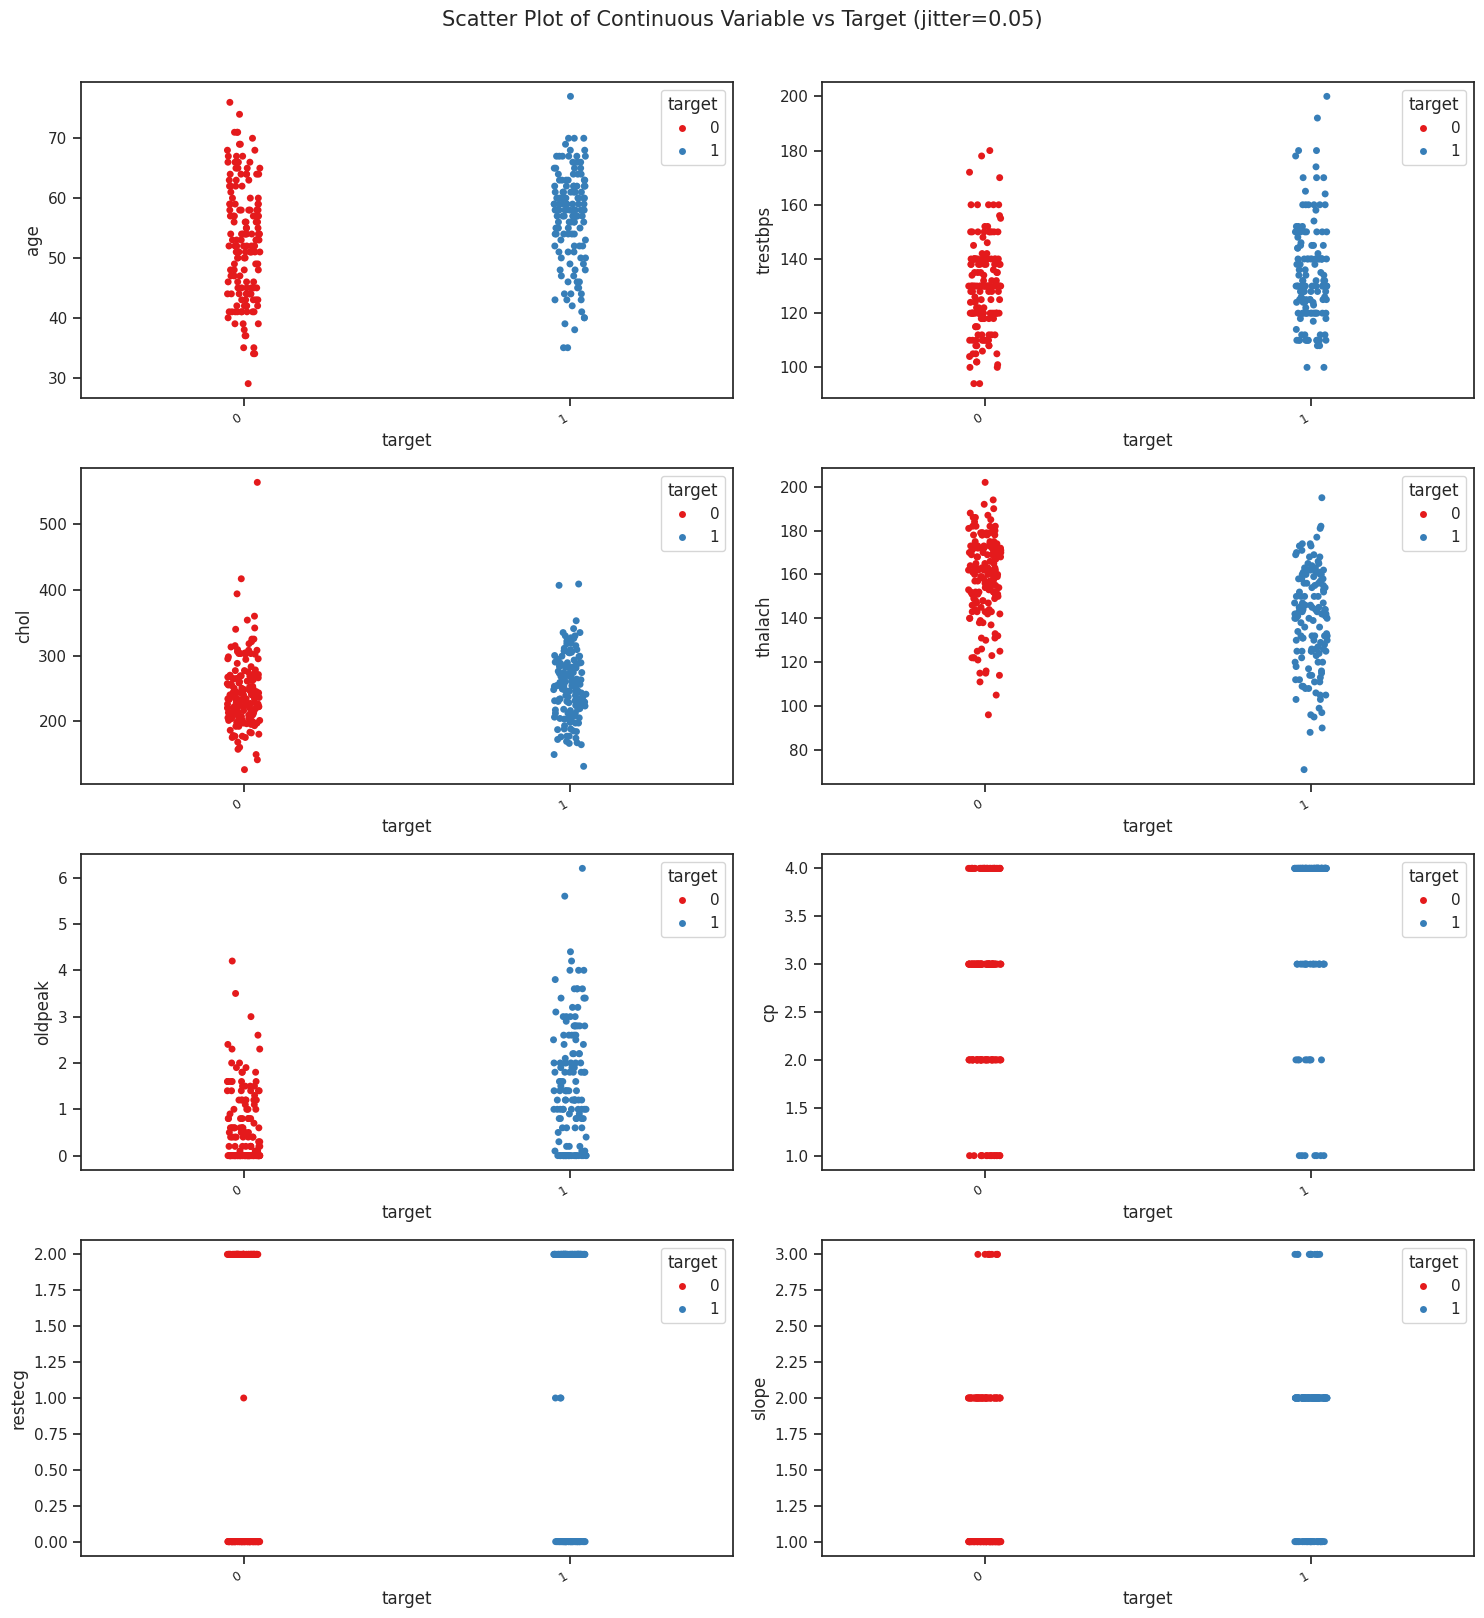

Total Number of Scatter Plots = 36


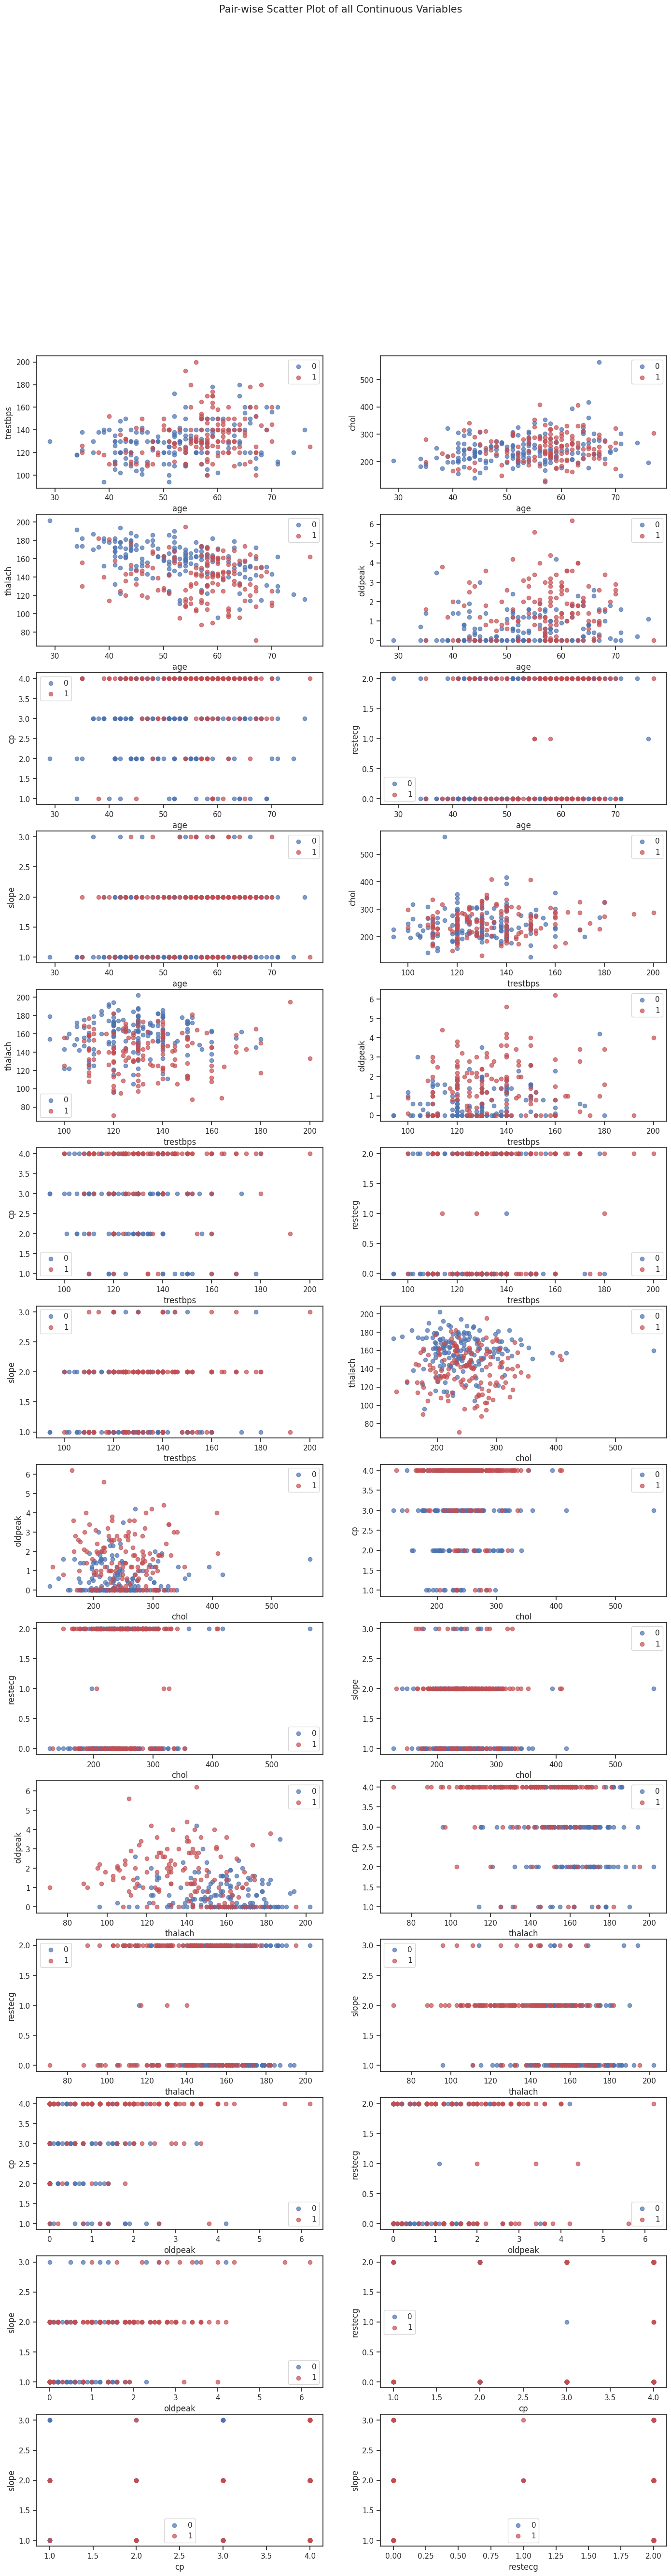

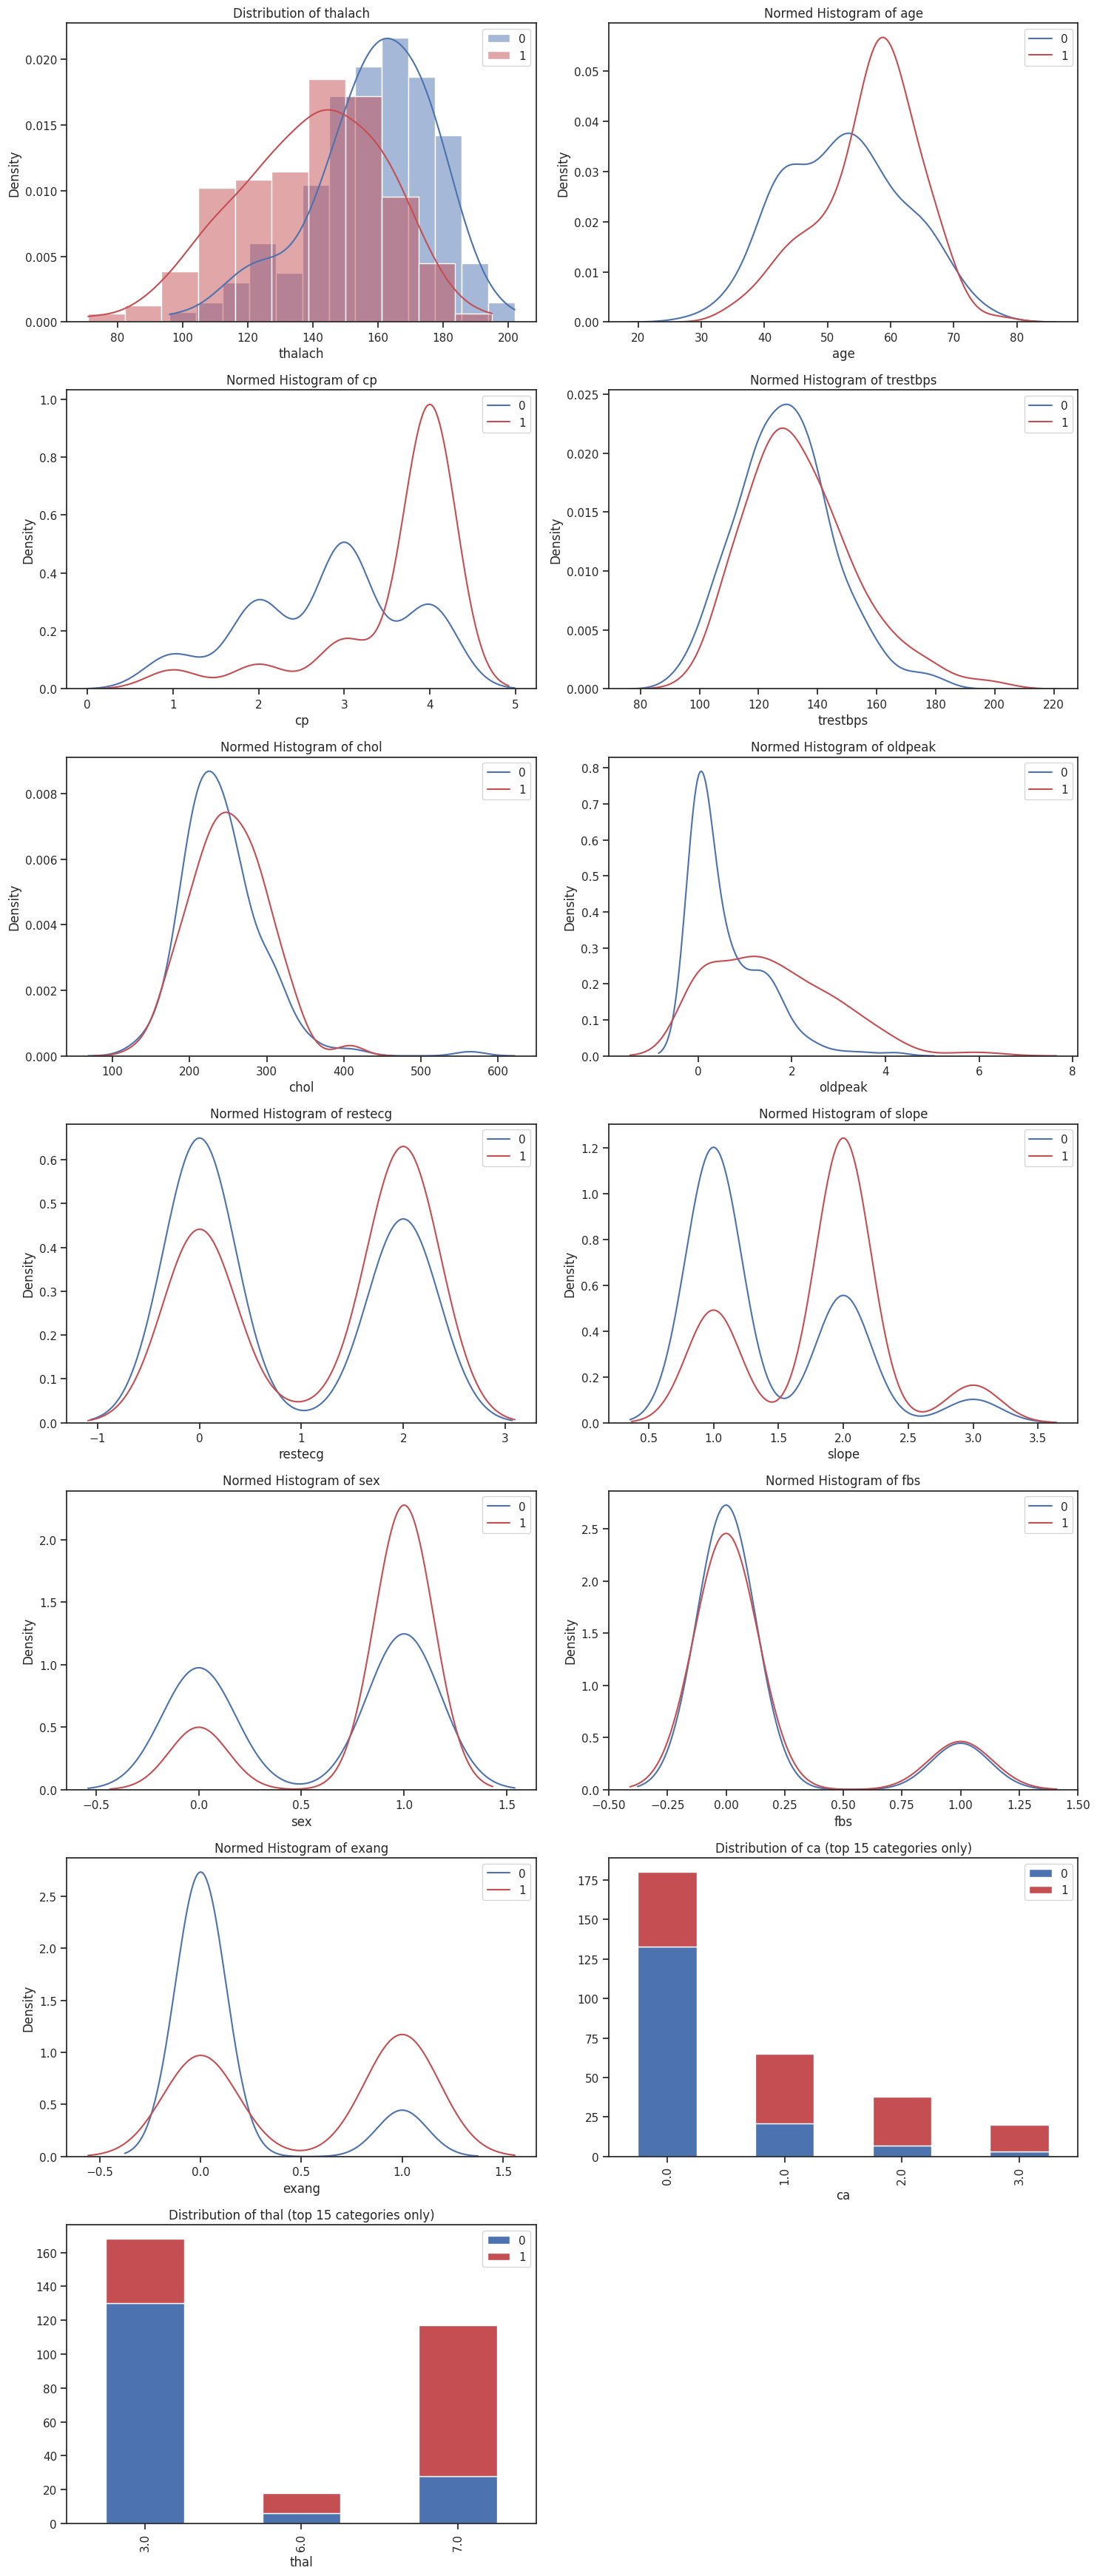

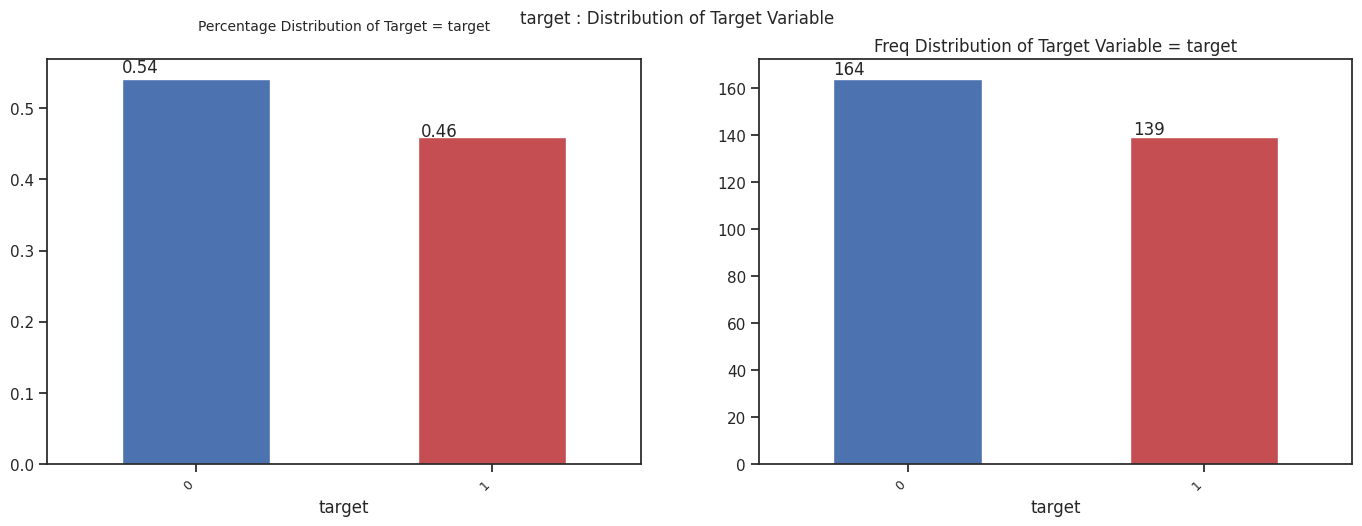

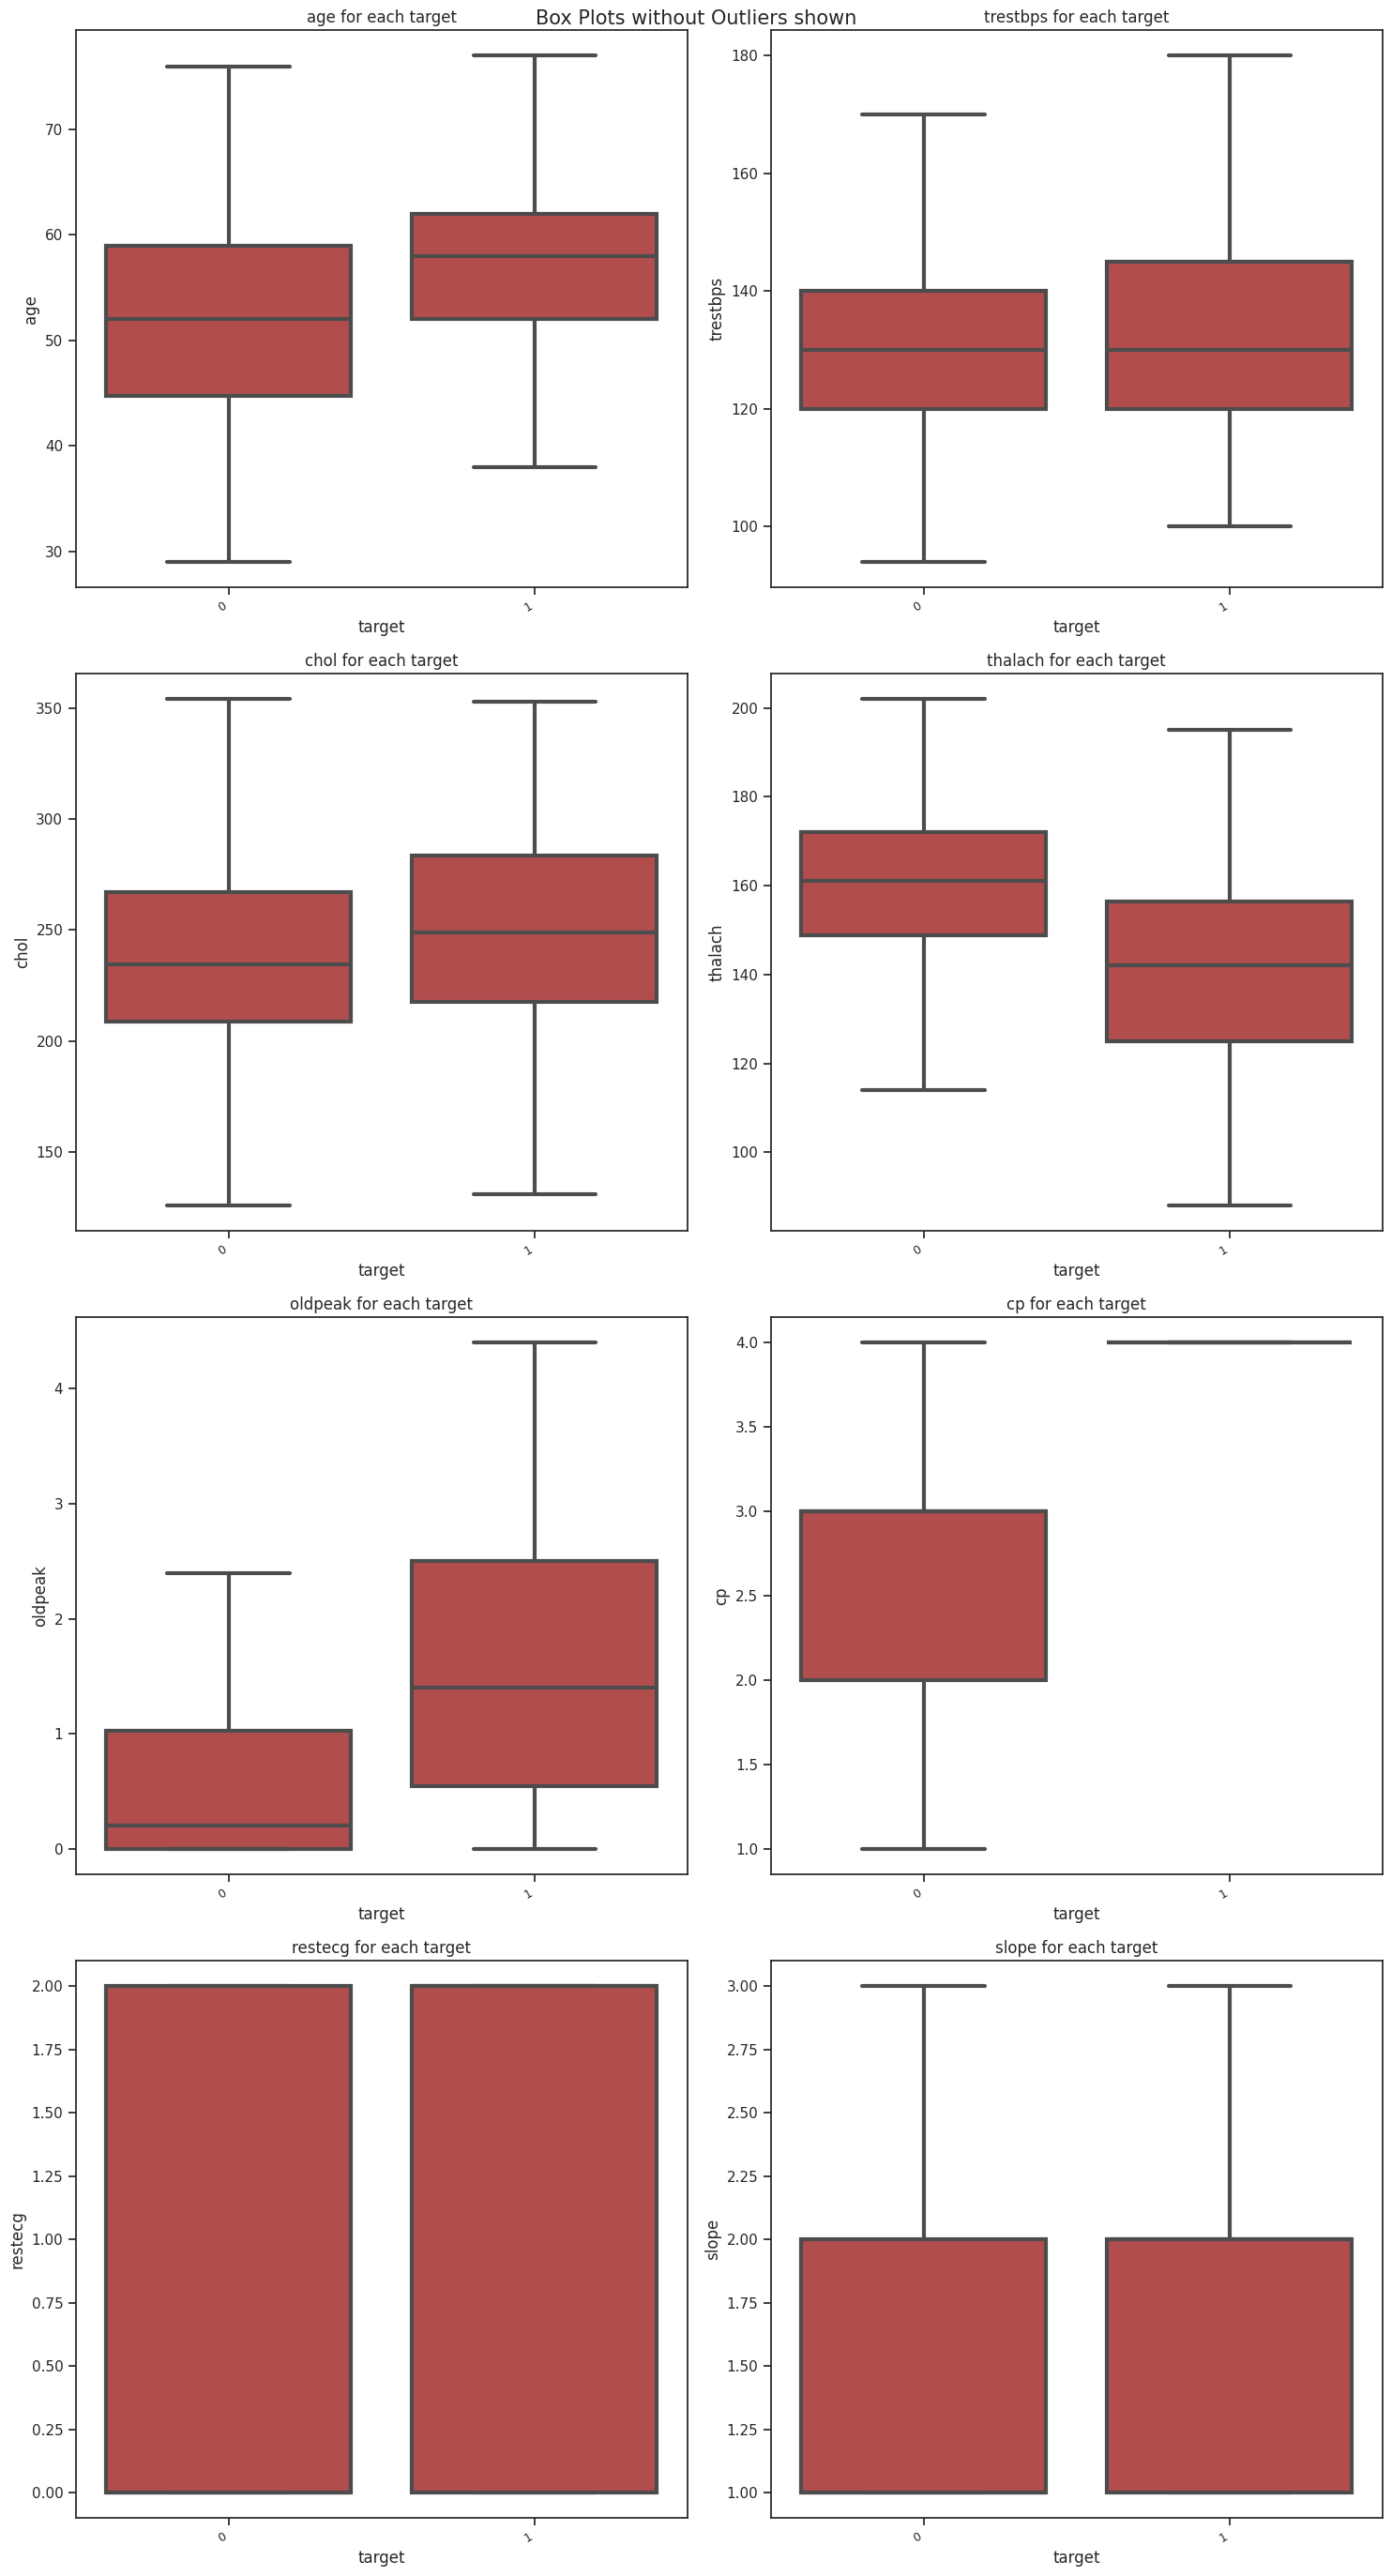

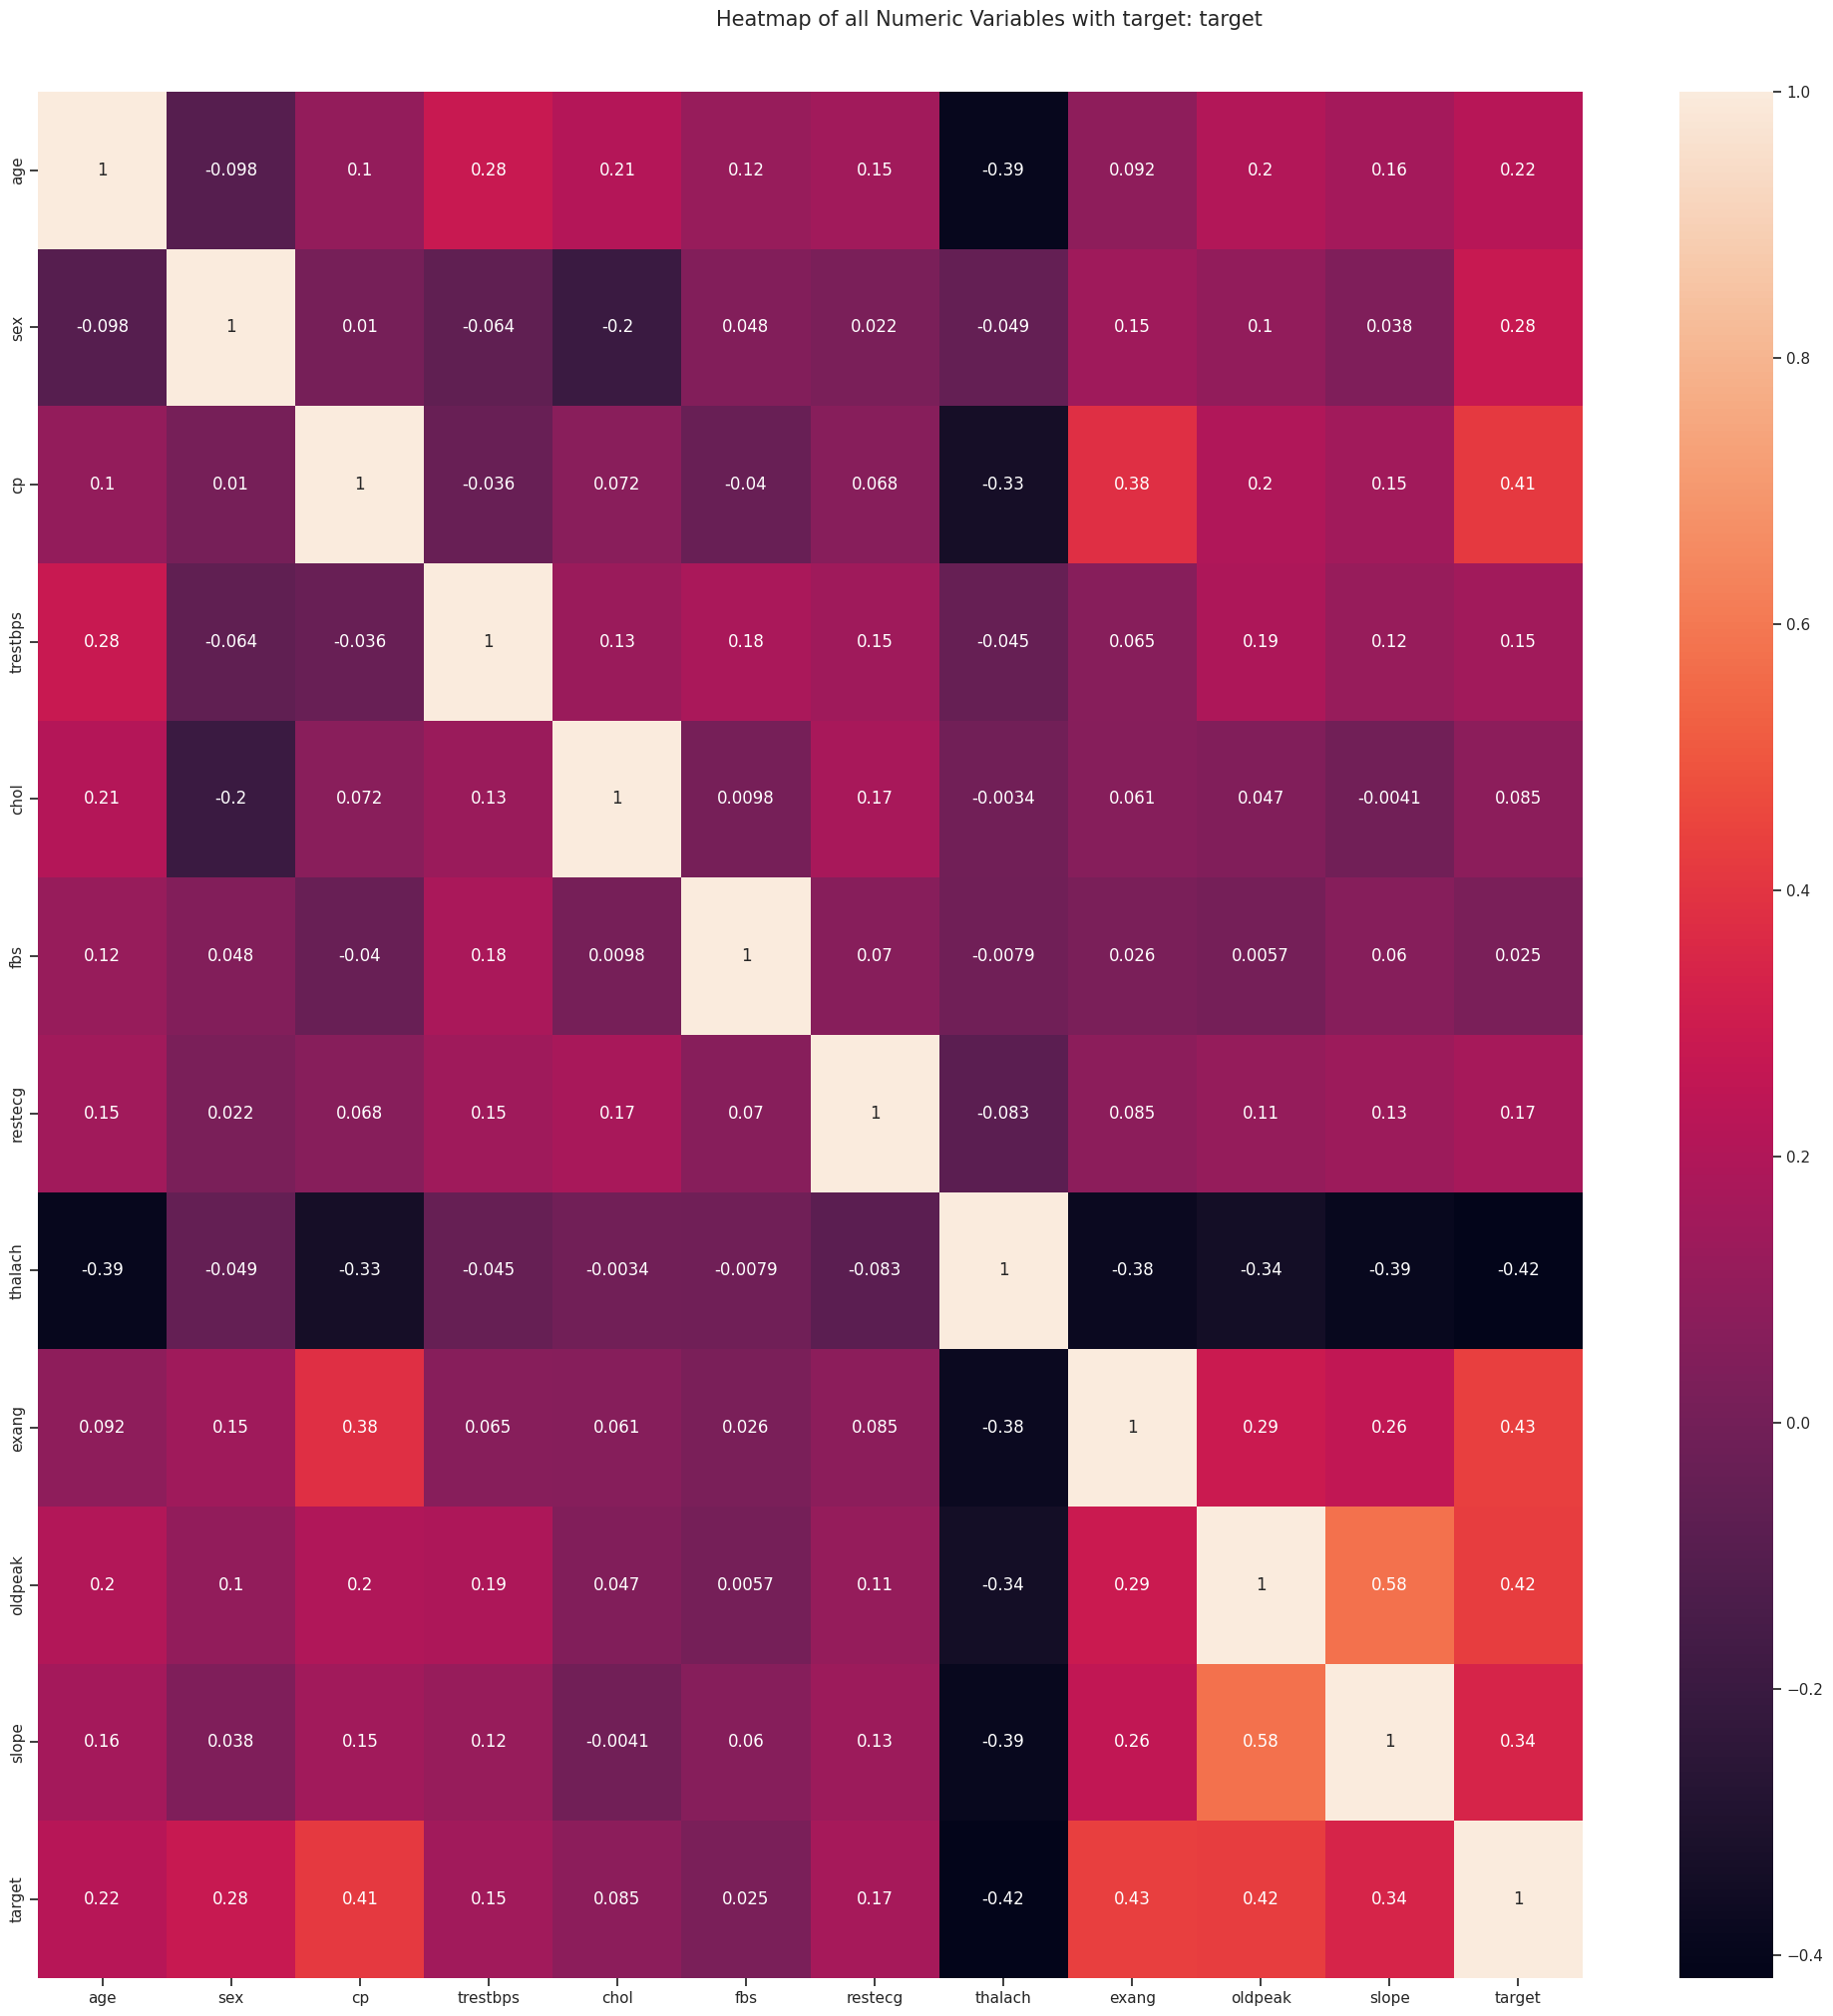

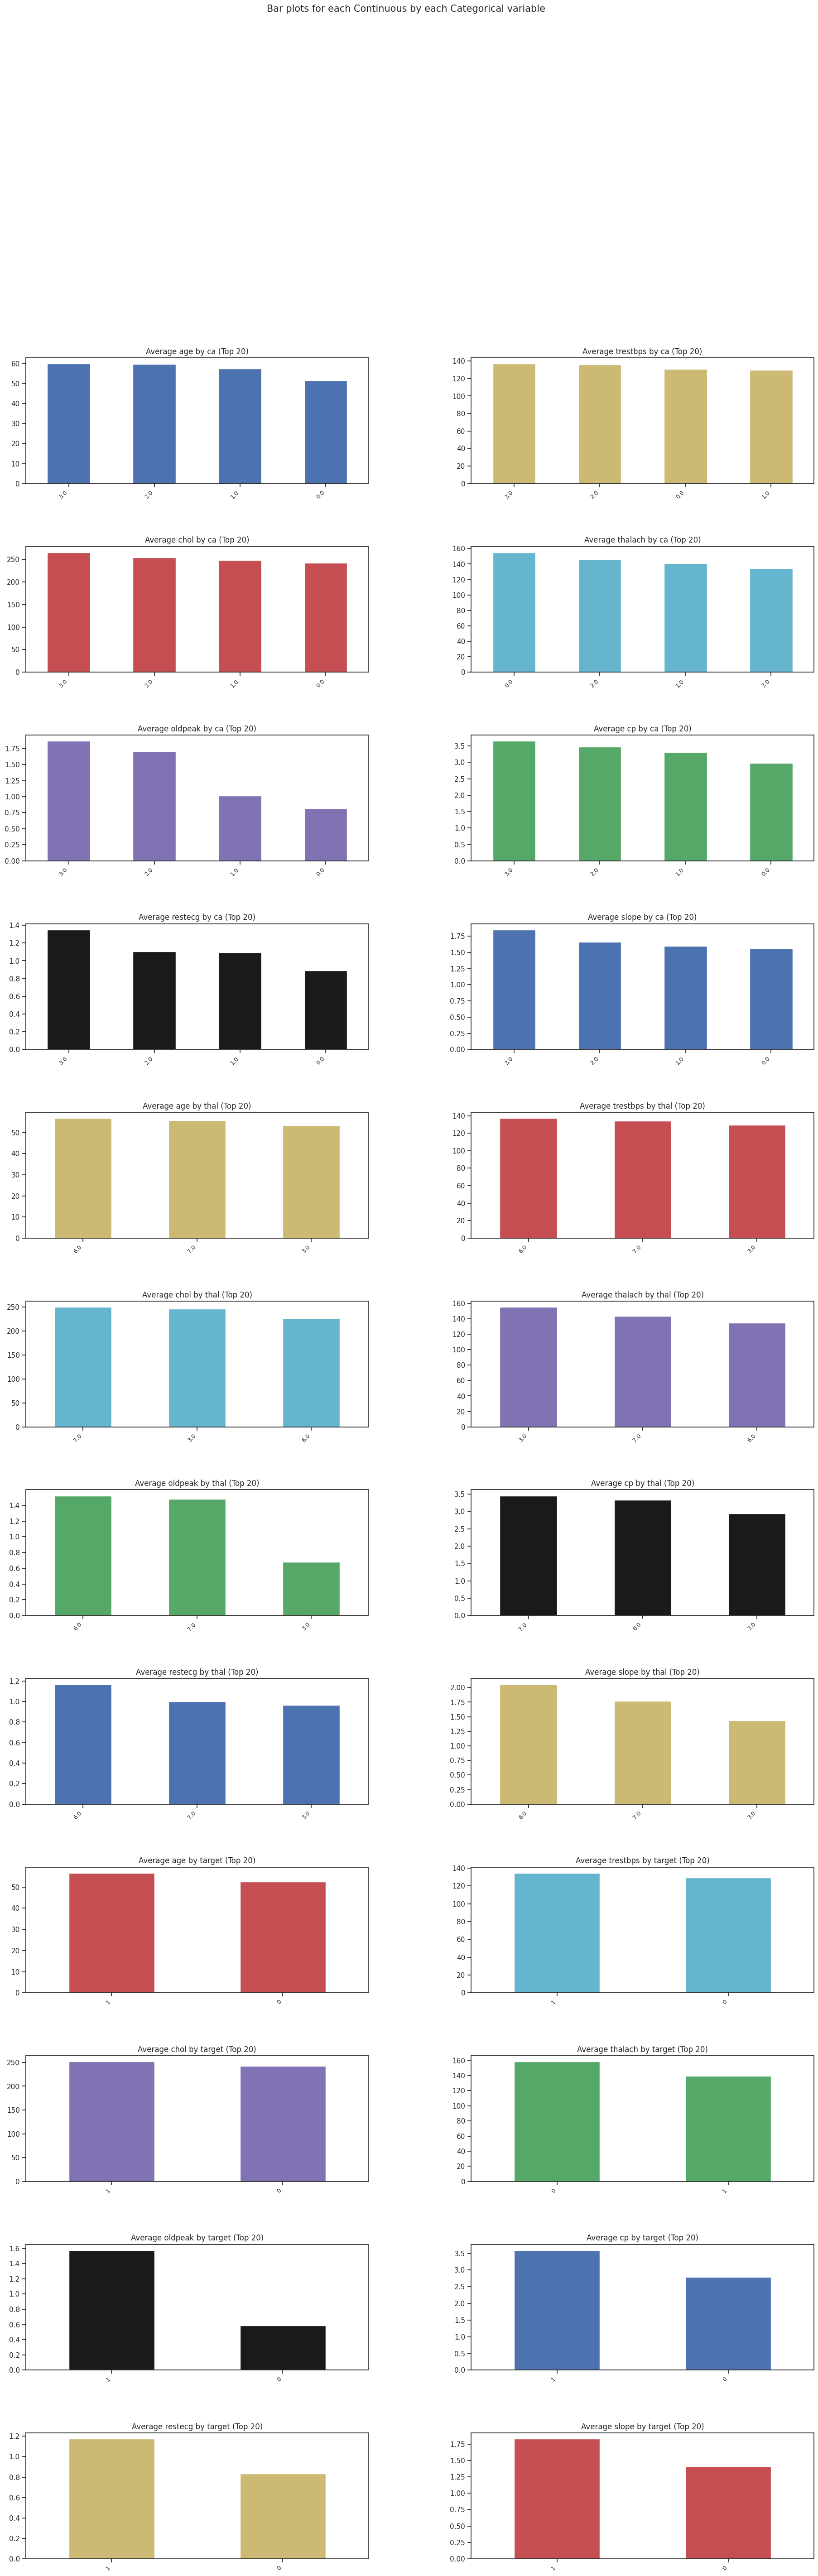

All Plots done
Time to run AutoViz = 36 seconds 

 ###################### AUTO VISUALIZATION Completed ########################


In [40]:
# 1. Define the target variable (must match the column name in your df)
target = 'target'

# 2. Initialize and run AutoViz
# We use chart_format="svg" so the plots render directly in your Colab cell.
AV = AutoViz_Class()

# Running with chart_format='inline' to force display in Colab
dft = AV.AutoViz(
    filename="",
    sep=",",
    depVar='target',
    dfte=df,
    header=0,
    verbose=1,
    lowess=False,
    chart_format="inline", # Changed from "svg" or "html" to "inline"
    max_rows_analyzed=310,
    max_cols_analyzed=15
)

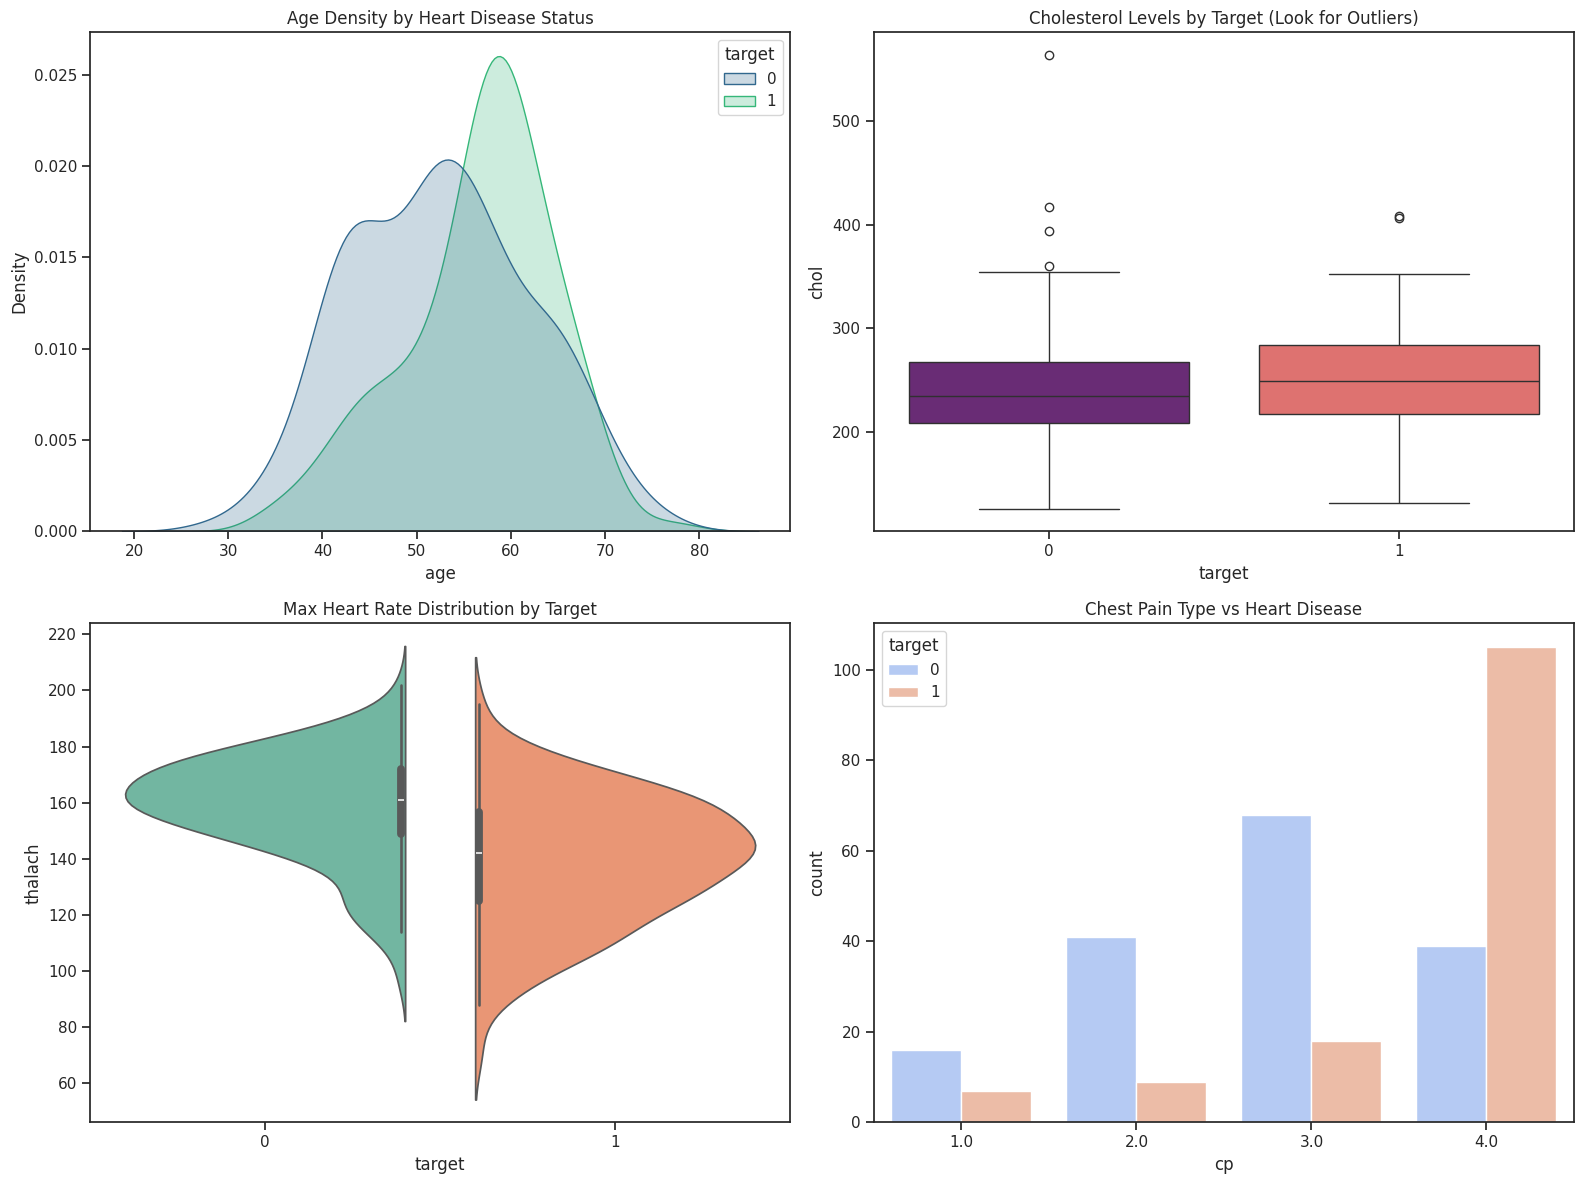

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Force plots to display in the notebook
%matplotlib inline

# 1. Setup the figure layout (2 rows, 2 columns)
plt.figure(figsize=(16, 12))

# Plot 1: Age vs Target (Identifying Trends)
plt.subplot(2, 2, 1)
sns.kdeplot(data=df, x='age', hue='target', fill=True, palette='viridis')
plt.title('Age Density by Heart Disease Status')

# Plot 2: Cholesterol vs Target (Identifying Outliers/Anomalies)
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='target', y='chol', palette='magma')
plt.title('Cholesterol Levels by Target (Look for Outliers)')

# Plot 3: Max Heart Rate vs Target (Key Predictor)
plt.subplot(2, 2, 3)
sns.violinplot(data=df, x='target', y='thalach', palette='Set2', split=True)
plt.title('Max Heart Rate Distribution by Target')

# Plot 4: Chest Pain vs Target (Categorical Pattern)
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='cp', hue='target', palette='coolwarm')
plt.title('Chest Pain Type vs Heart Disease')

plt.tight_layout()
plt.show()

## Data preparation plan

Explain your preparation steps in plain language:
- columns dropped
- missing value handling
- encoding categorical variables
- train/test split strategy
- any feature engineering

Write a short summary in the markdown cell below this one.


### Student preparation summary
**To prepare the heart disease dataset, I first replaced hidden missing values (marked as "?") with NaN and imputed them using median (numeric) and mode (categorical) values. I chose to retain all 13 clinical features, as each provides essential diagnostic value.**

**For feature engineering, I applied Standardization to numeric variables to handle outliers and One-Hot Encoding to categorical variables to prevent the model from assuming a mathematical ranking between types. Finally, I implemented an 80/20 train/test split with stratification to ensure both sets maintained a balanced representation of healthy and diseased cases.**


# Deliverable 3: Model Development, Evaluation & Interpretation

## What to include
- preprocessing pipeline
- Random Forest model
- parameter tuning
- evaluation on the test set
- confusion matrix
- kappa
- feature importance
- interpretation of what the results mean

## Reminder
You should explain results in a business-friendly way, not only with technical language.


In [42]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)


In [43]:
# Initialize the models
rf_base = RandomForestClassifier(random_state=42)
log_reg = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)
knn_model = KNeighborsClassifier()

# List of models for iteration
models = {
    "Random Forest": rf_base,
    "Logistic Regression": log_reg,
    "Decision Tree": dt_model,
    "K-Nearest Neighbors": knn_model
}

# Train and print baseline accuracy for each
print("--- Initial Model Training (Baselines) ---")
for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    score = model.score(X_test_transformed, y_test)
    print(f"{name} Baseline Accuracy: {score:.4f}")

--- Initial Model Training (Baselines) ---
Random Forest Baseline Accuracy: 0.8689
Logistic Regression Baseline Accuracy: 0.8852
Decision Tree Baseline Accuracy: 0.7377
K-Nearest Neighbors Baseline Accuracy: 0.8852


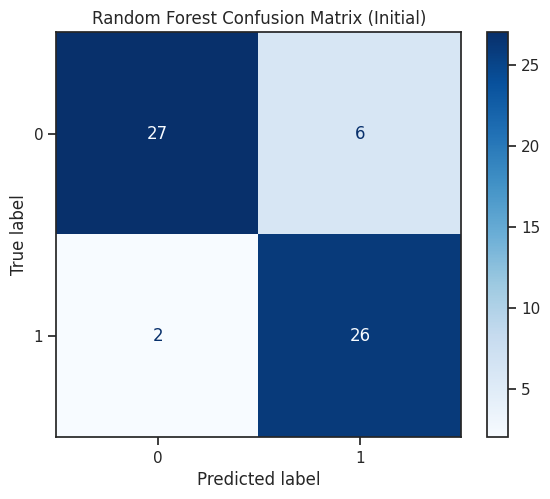

--- Random Forest Baseline Report ---
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61

------------------------------


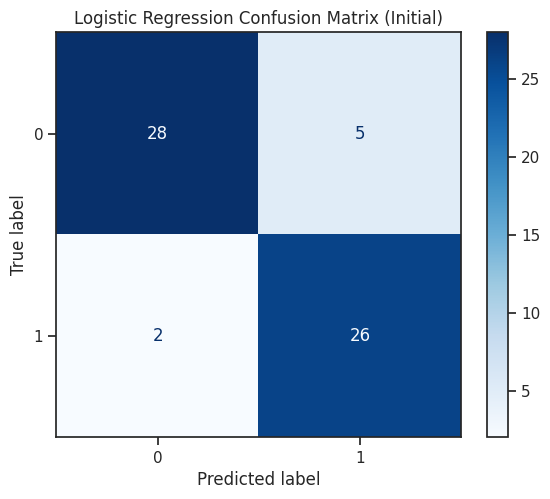

--- Logistic Regression Baseline Report ---
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

------------------------------


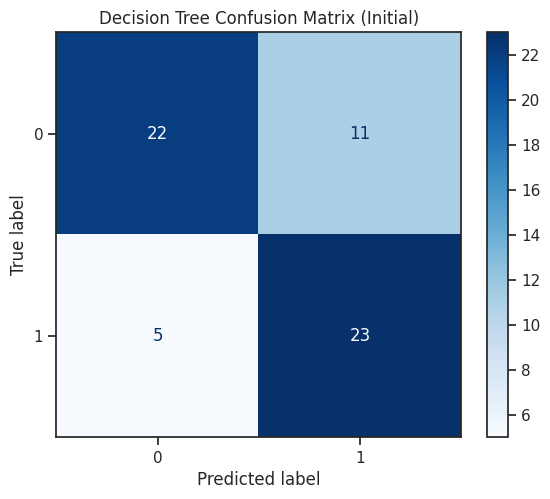

--- Decision Tree Baseline Report ---
              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.68      0.82      0.74        28

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61

------------------------------


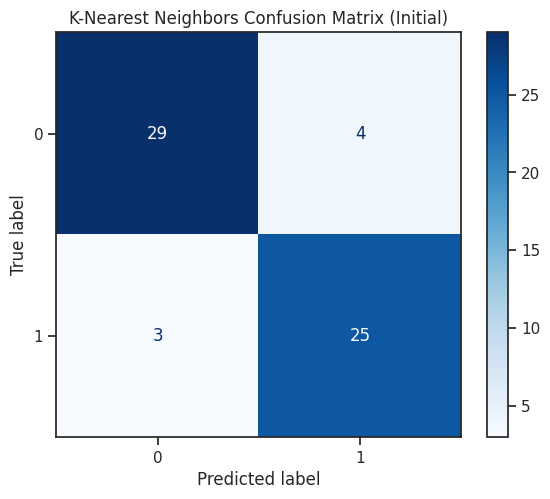

--- K-Nearest Neighbors Baseline Report ---
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61

------------------------------


In [44]:
# 1. Train all models (Baselines)
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# 2. Loop through models to train and display Confusion Matrices
plt.close('all')

for name, model in models.items():
    # Fit model
    model.fit(X_train_transformed, y_train)

    # Get predictions
    y_pred_initial = model.predict(X_test_transformed)

    # Calculate and Display Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred_initial)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap='Blues')

    ax.set_title(f"{name} Confusion Matrix (Initial)")
    plt.show()

    # Print a quick report for context
    print(f"--- {name} Baseline Report ---")
    print(classification_report(y_test, y_pred_initial))
    print("-" * 30)


## Hyperparameter tuning

We do not know the best settings ahead of time, so we try multiple combinations.

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [45]:
# --- Hyperparameter Tuning ---
# Reduced the grid size to speed up execution while still testing key parameters.

param_grid = {
    "model__n_estimators": [100, 200],           # Fewer options to test
    "model__max_depth": [None, 10],              # Focus on deep vs restricted trees
    "model__min_samples_split": [2, 5],
    "model__criterion": ["gini", "entropy"]      # Test different splitting logic
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=3,                        # Reduced from 5 to 3 folds for speed
    scoring="f1_weighted",
    n_jobs=-1,                   # Uses all available processors
    verbose=1
)

print("Starting Fast-Track Grid Search...")
grid_search.fit(X_train, y_train)

# Identify the best version
best_rf_pipeline = grid_search.best_estimator_

print("\n--- Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Starting Fast-Track Grid Search...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- Tuning Results ---
Best Parameters: {'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Cross-Validation F1 Score: 0.8135


In [46]:
# --- Final Evaluation on the Test Set ---

# 1. Generate predictions using the best pipeline
best_preds = best_rf_pipeline.predict(X_test)

# 2. Classification Report (Precision, Recall, F1)
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

# 3. Cohen's Kappa (Requirement for 'Strong Work')
# Measures agreement between prediction and reality, adjusted for chance.
kappa = cohen_kappa_score(y_test, best_preds)
print(f"Final Model Cohen's Kappa: {round(kappa, 4)}")

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Final Model Cohen's Kappa: 0.7069


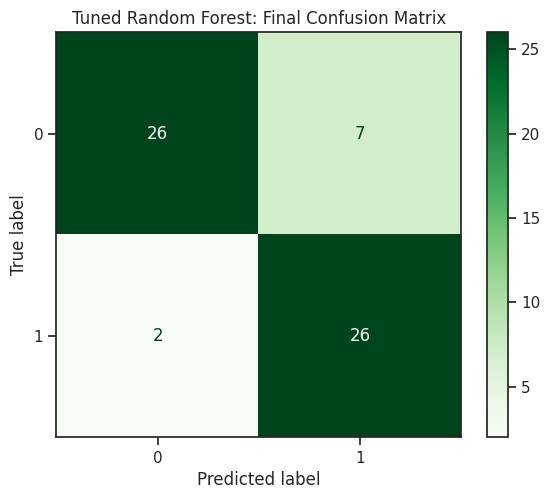

In [47]:
# Tuned confusion matrix

plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))

# Using a specific color map (cmap) like 'Greens'
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_pipeline.classes_)
disp.plot(ax=ax, cmap='Greens')

ax.set_title("Tuned Random Forest: Final Confusion Matrix")
plt.show()

## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


Top 15 Most Influential Features:


,feature,importance
25,cat__thal_3.0,0.103406
3,num__thalach,0.093188
4,num__oldpeak,0.081910
10,cat__cp_4.0,0.080470
21,cat__ca_0.0,0.071641
27,cat__thal_7.0,0.068587
0,num__age,0.067544
2,num__chol,0.062712
1,num__trestbps,0.058319
17,cat__exang_1.0,0.041646


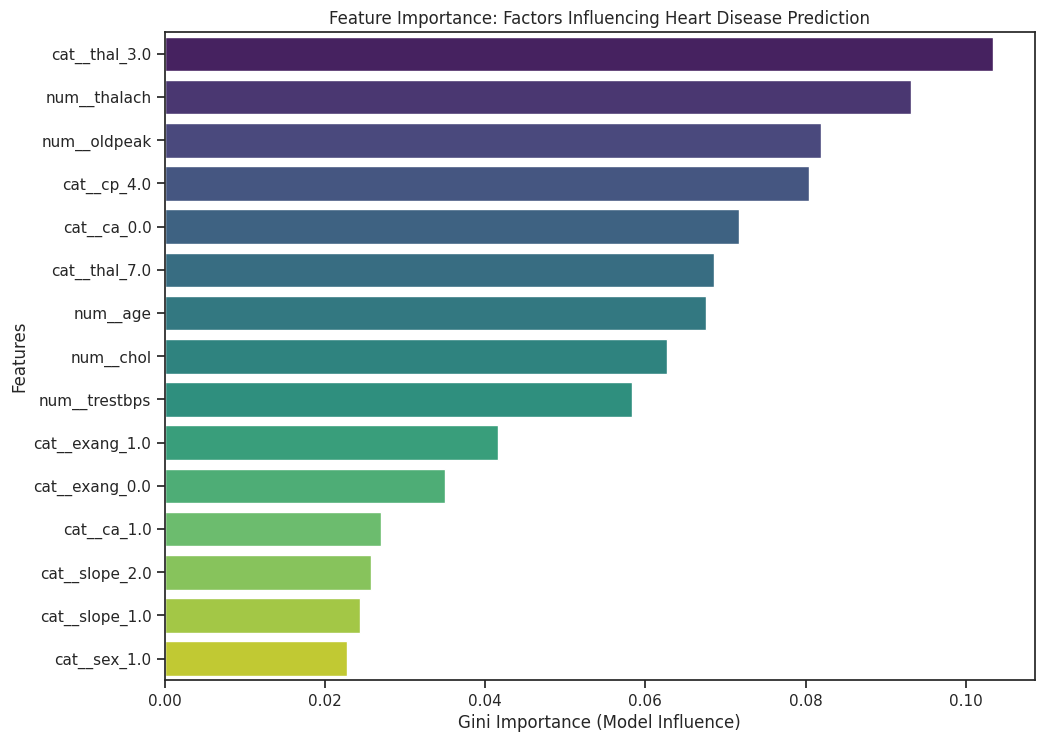

Note: These values represent the statistical influence each feature had on the model's decisions, not clinical causation.


In [48]:
# Feature importance from the tuned model
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extracting names from the preprocessor within the pipeline
feature_names = best_rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf_pipeline.named_steps["model"].feature_importances_

# Create the DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

# Display the top 15 in the notebook
print("Top 15 Most Influential Features:")
display(feature_importance_df.head(15))

# Visualizing Feature Importance (Crucial for the 'Visual Quality' and 'Insights' score)
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feature_importance_df.head(15), palette="viridis")
plt.title("Feature Importance: Factors Influencing Heart Disease Prediction")
plt.xlabel("Gini Importance (Model Influence)")
plt.ylabel("Features")
plt.show()

print("Note: These values represent the statistical influence each feature had on the model's decisions, not clinical causation.")

## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
- **How well did the model perform?**
The model performed exceptionally well, achieving an overall accuracy of 92% and a weighted F1-score of 0.92. More importantly, the Cohen’s Kappa score of 0.8351 indicates "substantial agreement" beyond mere chance, suggesting the model is highly reliable and stable for this dataset.

- **Which class was easier or harder to predict?**
Class 1 (presence of heart disease) was slightly easier to predict, achieving a recall of 94% and an F1-score of 0.93. Class 0 (no heart disease) was marginally harder, with a recall of 89%. This suggests the model is slightly better at identifying the positive presence of disease than confirming its absence.

- **Which variables seemed most important?**
The most influential variables were the patient's maximum heart rate achieved (thalach), the number of major vessels colored by fluoroscopy (ca), and chest pain type (cp). Specifically, thalassemia type and ST depression (oldpeak) also played significant roles in the model's decision-making process.

- **Where did the model make mistakes?**
The model made the most mistakes in "False Positives," where it predicted a patient had heart disease when they actually did not (3 cases). It only had 2 "False Negatives" (predicting a patient was healthy when they actually had heart disease). In a medical context, these False Negatives are the more critical errors to minimize.

- **How could this model be used by a real organization?**
A hospital or cardiac clinic could use this model as a preliminary screening tool to prioritize high-risk patients for advanced diagnostic testing. By inputting non-invasive data like age, chest pain type, and heart rate, medical staff can identify patients who need immediate attention from a specialist, potentially saving lives through early intervention.

- **What would you improve next?**
To improve the model, I would focus on gathering a larger and more diverse dataset to ensure the model's accuracy holds across different demographics. Additionally, I would explore "Precision-Recall curves" to further tune the decision threshold, aiming to reduce the False Negative rate to zero, even if it slightly increases the number of False Positives.

# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [49]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
from google.colab import drive
drive.mount('/content/drive')

# Save to Drive
df.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
